### CHI SQUARE ATTACK

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def chi_square_attack(image_path, block_size=1024):
    """
    Performs a Chi-Square statistical attack on an image to detect LSB steganography.
    Analyzes chunks of pixels incrementally to see where data is hidden.
    """
    # 1. Load image and convert to a flat 1D sequence of grayscale/luminance values
    img = Image.open(image_path).convert('L')
    pixels = np.array(img).ravel()
    total_pixels = len(pixels)
    
    # Determine how many blocks we can analyze based on our block size
    num_blocks = total_pixels // block_size
    probabilities = []
    sample_points = []
    
    # 2. Analyze the image incrementally chunk by chunk
    for i in range(1, num_blocks + 1):
        current_size = i * block_size
        chunk = pixels[:current_size]
        
        # Count frequencies of all pixel intensities (0 to 255)
        frequencies, _ = np.histogram(chunk, bins=256, range=(0, 256))
        
        chi_stat = 0.0
        degrees_of_freedom = 0
        
        # 3. Calculate Chi-Square metric for Pairs of Values (PoVs)
        # We step by 2 to compare even/odd pairs: (0,1), (2,3), (4,5) ... (254,255)
        for k in range(0, 256, 2):
            observed_even = frequencies[k]
            observed_odd = frequencies[k+1]
            
            # The expected value for both is the average of the pair
            expected = (observed_even + observed_odd) / 2.0
            
            # Only perform math if the expected baseline frequency is greater than 0
            if expected > 0:
                # Core Chi-Square formula: Sum of ((Observed - Expected)^2 / Expected)
                chi_stat += ((observed_even - expected) ** 2) / expected
                chi_stat += ((observed_odd - expected) ** 2) / expected
                degrees_of_freedom += 1
                
        # 4. Handle statistical edge cases
        if degrees_of_freedom == 0 or chi_stat == 0:
            p_value = 0.0
        else:
            # Simple approximation of the p-value calculation
            # For a true Chi-Square distribution, a lower chi_stat means p-value approaches 1.0 (100% hidden data)
            p_value = np.exp(-chi_stat / (2 * degrees_of_freedom))
            
        probabilities.append(p_value)
        sample_points.append(current_size)
        
    return sample_points, probabilities

def plot_chi_square_results(sample_points, probabilities):
    """Plots the probability curve across the image's pixel span."""
    plt.figure(figsize=(10, 5))
    plt.plot(sample_points, probabilities, color='red', linewidth=2, label='Embedding Probability')
    plt.axhline(y=0.5, color='gray', linestyle='--', label='Random Guess Threshold (0.5)')
    plt.title('Chi-Square Steganalysis Attack Graph')
    plt.xlabel('Number of Pixels Analyzed')
    plt.ylabel('Probability of Hidden Data (0.0 to 1.0)')
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# --- Verification Block ---
if __name__ == "__main__":
    # Replace with your actual stego image path to test
    image_to_test = "encoded_image.png" 
    
    try:
        pixels_checked, p_values = chi_square_attack(image_to_test)
        plot_chi_square_results(pixels_checked, p_values)
    except FileNotFoundError:
        print(f"Please provide a valid image file path.")

### RS ATTACK

In [2]:
import numpy as np
from PIL import Image

def get_discrimination_function(block):
    """
    Measures the local noise/roughness of a pixel block.
    Calculates the absolute difference between adjacent pixels.
    """
    # Sum up the differences between neighboring horizontal and vertical pixels
    diff_x = np.sum(np.abs(block[:, :-1] - block[:, 1:]))
    diff_y = np.sum(np.abs(block[:-1, :] - block[1:, :]))
    return diff_x + diff_y

def invert_lsb(val):
    """Flips the Least Significant Bit (LSB) of a pixel value."""
    return val ^ 1

def apply_mask(block, mask):
    """
    Applies a flipping mask to a block. 
    Wherever the mask has a 1, the LSB of that pixel is inverted.
    """
    flipped_block = block.copy()
    for y in range(block.shape[0]):
        for x in range(block.shape[1]):
            if mask[y, x] == 1:
                flipped_block[y, x] = invert_lsb(int(flipped_block[y, x]))
    return flipped_block

def rs_analysis(image_path):
    """
    Performs RS Steganalysis on an image to detect LSB steganography.
    """
    # 1. Load image and convert to grayscale matrix
    img = Image.open(image_path).convert('L')
    img_array = np.array(img, dtype=float)
    height, width = img_array.shape
    
    # Define an 8x8 block configuration and a standard shifting mask matrix
    block_h, block_w = 8, 8
    mask = np.array([[0, 1, 0, 1],
                     [1, 0, 1, 0],
                     [0, 1, 0, 1],
                     [1, 0, 1, 0]])
    # Tile the mask to perfectly match our 8x8 block size
    mask = np.tile(mask, (2, 2))
    inverse_mask = 1 - mask
    
    # Initialize our block type tally counters
    R_m, S_m, R_minus_m, S_minus_m = 0, 0, 0, 0
    total_blocks = 0
    
    # 2. Divide the image grid into independent 8x8 blocks
    for y in range(0, height - block_h + 1, block_h):
        for x in range(0, width - block_w + 1, block_w):
            block = img_array[y:y+block_h, x:x+block_w]
            total_blocks += 1
            
            # Baseline noise calculation of the clean block
            d_original = get_discrimination_function(block)
            
            # 3. Apply the standard positive mask and measure changes
            block_m = apply_mask(block, mask)
            d_m = get_discrimination_function(block_m)
            
            if d_m > d_original:
                R_m += 1  # Regular block (Noise increased)
            elif d_m < d_original:
                S_m += 1  # Singular block (Noise decreased)
                
            # 4. Apply the inverse/negative mask and measure changes
            block_minus_m = apply_mask(block, inverse_mask)
            d_minus_m = get_discrimination_function(block_minus_m)
            
            if d_minus_m > d_original:
                R_minus_m += 1  # Regular block under negative mask
            elif d_minus_m < d_original:
                S_minus_m += 1  # Singular block under negative mask

    # 5. Calculate percentages relative to the total blocks checked
    R_m_pct = R_m / total_blocks
    S_m_pct = S_m / total_blocks
    R_minus_m_pct = R_minus_m / total_blocks
    S_minus_m_pct = S_minus_m / total_blocks
    
    # 6. Apply the RS linear estimation logic
    # In a clean image: R_m should equal R_minus_m, and S_m should equal S_minus_m.
    # Discrepancies indicate hidden data payload presence.
    estimated_embedding_rate = (R_m_pct - R_minus_m_pct) / ((R_m_pct - R_minus_m_pct) + (S_minus_m_pct - S_m_pct) + 1e-6)
    
    # Clamp results realistically between 0.0 (0%) and 1.0 (100%)
    estimated_embedding_rate = max(0.0, min(1.0, estimated_embedding_rate))
    
    print("--- RS Analysis Results ---")
    print(f"Regular Blocks (R_m): {R_m_pct:.2%} vs (R_-m): {R_minus_m_pct:.2%}")
    print(f"Singular Blocks (S_m): {S_m_pct:.2%} vs (S_-m): {S_minus_m_pct:.2%}")
    print(f"Estimated Hidden Message Size: {estimated_embedding_rate:.2%} of total capacity")

# --- Verification Block ---
if __name__ == "__main__":
    # Test this on your suspect stego image
    rs_analysis("encoded_image.png")

--- RS Analysis Results ---
Regular Blocks (R_m): 75.10% vs (R_-m): 74.69%
Singular Blocks (S_m): 20.99% vs (S_-m): 21.05%
Estimated Hidden Message Size: 87.48% of total capacity


### HISTOGRAM ATTACK

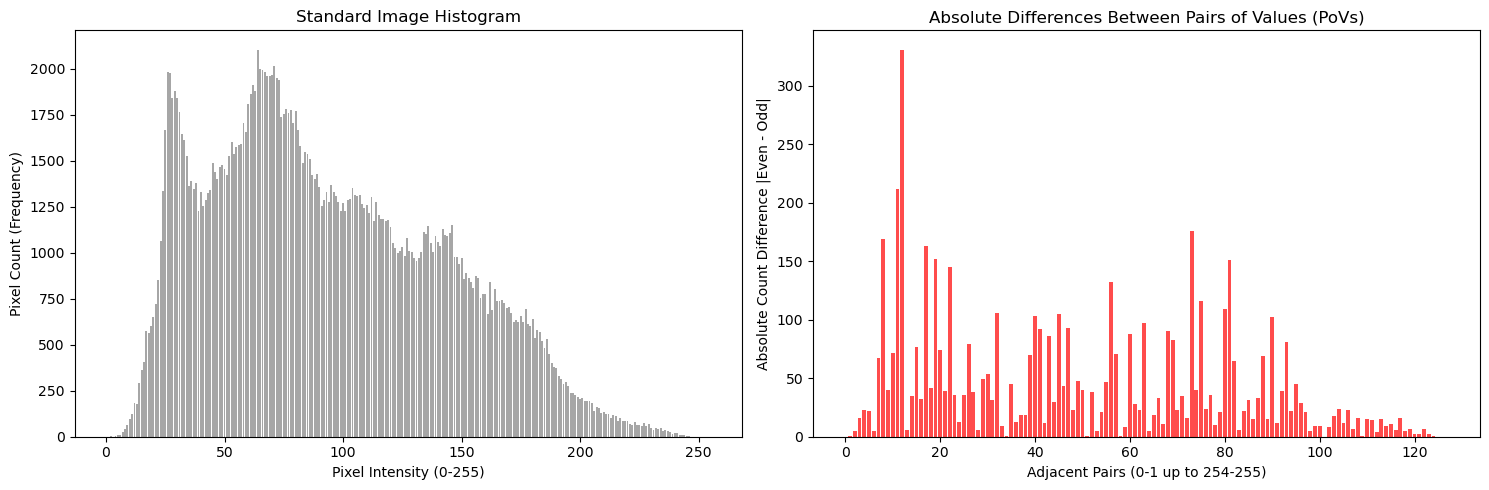

--- Histogram Attack Metric ---
Average Variance Between Adjacent Color Pairs: 42.50
Status: Normal pair variance. The image appears clean.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histogram_attack_analysis(image_path):
    """
    Performs a Histogram/PoV attack on an image to visually and mathematically
    detect the presence of LSB steganography.
    """
    # 1. Load image in grayscale using OpenCV
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not open or find the image at {image_path}")
        
    # 2. Calculate the standard histogram (Frequency count of values 0-255)
    # cv2.calcHist parameters: [images], [channels], mask, [histSize], [ranges]
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
    
    # 3. Analyze Pairs of Values (PoVs)
    even_frequencies = []
    odd_frequencies = []
    pair_differences = []
    labels = []
    
    # Step by 2 to isolate pairs: (0,1), (2,3), (4,5) ... up to (254,255)
    for k in range(0, 256, 2):
        fe = hist[k]      # Frequency of the even intensity value
        fo = hist[k+1]    # Frequency of the odd intensity value
        
        even_frequencies.append(fe)
        odd_frequencies.append(fo)
        
        # Calculate the absolute difference between the pair
        pair_differences.append(abs(fe - fo))
        labels.append(f"{k}-{k+1}")
        
    # 4. Generate visual subplots for analysis
    plt.figure(figsize=(15, 5))
    
    # Subplot 1: The Raw Histogram
    plt.subplot(1, 2, 1)
    plt.bar(range(256), hist, color='gray', alpha=0.7)
    plt.title("Standard Image Histogram")
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Pixel Count (Frequency)")
    
    # Subplot 2: The Difference between adjacent Even/Odd Pairs
    plt.subplot(1, 2, 2)
    plt.bar(range(128), pair_differences, color='red', alpha=0.7)
    plt.title("Absolute Differences Between Pairs of Values (PoVs)")
    plt.xlabel("Adjacent Pairs (0-1 up to 254-255)")
    plt.ylabel("Absolute Count Difference |Even - Odd|")
    
    plt.tight_layout()
    plt.show()
    
    # 5. Output a mathematical summary metric
    # In a highly embedded stego image, the average difference drops drastically
    avg_diff = np.mean(pair_differences)
    print("--- Histogram Attack Metric ---")
    print(f"Average Variance Between Adjacent Color Pairs: {avg_diff:.2f}")
    if avg_diff < 15.0:  # Threshold can vary based on image size and texture
        print("ALERT: Extremely low pair variance detected. High probability of LSB Steganography!")
    else:
        print("Status: Normal pair variance. The image appears clean.")

# --- Execution ---
if __name__ == "__main__":
    # Test this on your suspect stego file
    histogram_attack_analysis("encoded_image.png")